# Working with LLMs: Other Modalities — Speech & Video

Last class the model only ever read **text**. Today it listens and it watches.

Two halves, one idea running through both:

> **A model never "hears" a sound or "sees" a video. It reads a tensor you built.**
> Almost every bug in production audio/video is a bug in *how you built that tensor* —
> wrong sample rate, wrong shape, wrong frames, no timestamps.

So the job is never "call the fancy model". The job is **choosing what to hand it**.

```
                     WORKING WITH LLMs · OTHER MODALITIES

  ┌──────────────────────────── SPEECH ──────────────────────────────┐
  │                                                                  │
  │    air pressure  ──►  numbers  ──►  frequencies  ──►  a model    │
  │         P1              P1              P2                       │
  │                                                                  │
  │    P3   get the numbers RIGHT    Nyquist · sample-rate footguns  │
  │    P4   open-source ASR          Whisper · VAD · WER · long form │
  │    P5   managed ASR / TTS        gpt-4o-transcribe · -mini-tts   │
  └──────────────────────────────────────────────────────────────────┘

  ┌──────────────────────────── VISION ──────────────────────────────┐
  │                                                                  │
  │    P6   ONE image      ──►  image_url · base64 · Responses API   │
  │    P7   a VIDEO        ──►  frames YOU chose (decode · sample)   │
  │    P8   frames + [t]   ──►  now it can reason about TIME         │
  │    P9   + transcript   ──►  the pattern you actually ship        │
  └──────────────────────────────────────────────────────────────────┘
```

## Part 0 · Setup

Four cells: installs, imports, the API key, and the handful of constants the
whole notebook reads.

> **Real-world gotcha (audio decoding).** Recent `datasets` versions decode audio
> through `torchcodec`/`ffmpeg`, which is broken on a lot of machines (this one
> included). The pattern used throughout: load with `Audio(decode=False)` and
> decode the raw bytes yourself with `soundfile`. If an audio cell explodes on
> your box, it is almost always the environment, not the code.

In [1]:
# One-time installs. torchaudio is NOT optional -- Silero VAD imports it (P4).
#!pip install -q numpy librosa soundfile transformers datasets jiwer torchaudio \
#               openai python-dotenv opencv-python imageio-ffmpeg ipython-autotime

In [2]:
# autotime prints how long every cell took -- useful when you start timing
# model calls against API calls.
%load_ext autotime

time: 95 µs (started: 2026-08-25 11:06:04 +05:30)


In [3]:
import os, json, base64, subprocess, warnings
from pathlib import Path

import numpy as np
import librosa
import soundfile as sf
import torch
import cv2
import matplotlib.pyplot as plt
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "#FCFAF4", "axes.grid": True,
    "grid.color": "#E6E0D4", "axes.titleweight": "bold", "font.size": 10,
})

device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")

print("numpy", np.__version__, "| librosa", librosa.__version__,
      "| torch", torch.__version__, "| cv2", cv2.__version__)
print("device:", device)

numpy 2.3.3 | librosa 0.11.0 | torch 2.10.0 | cv2 4.13.0
device: mps
time: 872 ms (started: 2026-08-25 11:06:04 +05:30)


In [4]:
import textwrap
from dotenv import load_dotenv
from openai import OpenAI

# Optional -- only needed if you are behind a VPN, as I am.
import truststore
truststore.inject_into_ssl()


def pretty_print(*args):
    text = " ".join(str(arg) for arg in args)
    try:
        print(textwrap.fill(text, width=80))
    except Exception:
        print(text)


load_dotenv('/Users/shivam13juna/Documents/scaler/GEN_AI_REF/openai_key.env')

if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("OPENAI_API_KEY not found! Check the path in load_dotenv above.")

client = OpenAI()
pretty_print("API key loaded, client ready.")

API key loaded, client ready.
time: 422 ms (started: 2026-08-25 11:06:05 +05:30)


In [5]:
# ---- everything the notebook is configured by, in one place ---------------

SR = 16_000                              # THE speech sample rate. Everything is 16k.

ASR_MODEL_ID = "openai/whisper-base.en"  # fast classroom default (73M params)
# ASR_MODEL_ID = "openai/whisper-large-v3-turbo"   # what you'd actually ship

VISION_MODEL = "gpt-5-nano"              # any vision model: gpt-4o, gpt-4.1, gpt-5-*
OPENAI_ASR   = "gpt-4o-transcribe"       # managed speech-to-text
OPENAI_TTS   = "gpt-4o-mini-tts"         # managed text-to-speech
SEGMENT_ASR  = "whisper-1"               # the only one that returns SEGMENT timestamps

VIDEO_PATH = "/Users/shivam13juna/Documents/scaler/GEN_AI_REF/AI Modalities: Video/videos/what_is_your_name.mp4"

CACHE = Path("audio_cache")              # pre-fetched clips live here

print("ASR (local) :", ASR_MODEL_ID)
print("vision      :", VISION_MODEL)
print("video       :", Path(VIDEO_PATH).name, "|  exists:", os.path.exists(VIDEO_PATH))

ASR (local) : openai/whisper-base.en
vision      : gpt-5-nano
video       : what_is_your_name.mp4 |  exists: True
time: 534 µs (started: 2026-08-25 11:06:06 +05:30)


`SPEECH ▸ ` **P1 numbers** ▸ P2 frequencies ▸ P3 footguns ▸ P4 Whisper ▸ P5 OpenAI `  ·  VISION ▸ ` P6 images ▸ P7 frames ▸ P8 +time ▸ P9 +transcript

## Part 1 · Sound is just numbers

Sound is air pressure wobbling over time. To digitise it you **measure that
pressure many times a second**. That is the whole idea — the result is a 1-D
array of floats. Nothing more exotic than a list of numbers.

Two knobs decide what that array *means*:

| Knob | Controls | Typical values | Who cares |
|---|---|---|---|
| **Sample rate** (`sr`, Hz) | how *often* you measured — the time axis | 8k phone · **16k speech AI** · 24k TTS · 44.1k/48k music | **everyone — the #1 footgun** |
| **Amplitude** (the values) | how *loud* each sample is, and how it is stored | `float32` in [-1, 1] for models · `int16` in files | loaders / normalisation |

> **Sample rate is the number you will get wrong.** Whisper wants 16 kHz, TTS
> usually emits 24 kHz, music is 44.1 kHz. Hand a model the wrong rate and it does
> **not** raise — it quietly returns garbage. Burn this in now and you have dodged
> the single most common audio bug in your career.

Start with the thing your ear already knows: **frequency is pitch.**

In [6]:
# Frequency = how fast the wave wobbles = what you hear as PITCH.
# Same amplitude (0.3) every time, so the ONLY thing changing is speed.
sr_demo, duration = 44_100, 2.0
t = np.linspace(0, duration, int(sr_demo * duration), endpoint=False)

for hz, label in [(100, "deep"), (1000, "sharp"), (10_000, "very sharp"),
                  (15_000, "near the top of adult hearing")]:
    print(f"{hz:>6} Hz  ({label})")
    display(Audio(0.3 * np.sin(2 * np.pi * hz * t), rate=sr_demo))

   100 Hz  (deep)


  1000 Hz  (sharp)


 10000 Hz  (very sharp)


 15000 Hz  (near the top of adult hearing)


time: 7.38 ms (started: 2026-08-25 11:06:06 +05:30)


Two words that sound the same and are not:

- **sound frequency** = how fast the *sound itself* vibrates (pitch, in Hz)
- **sampling rate** = how fast the *microphone/computer measures it* (also Hz)

The plot below is deliberately tiny — a 2 Hz wave sampled 8 times a second — so
you can literally count the dots.

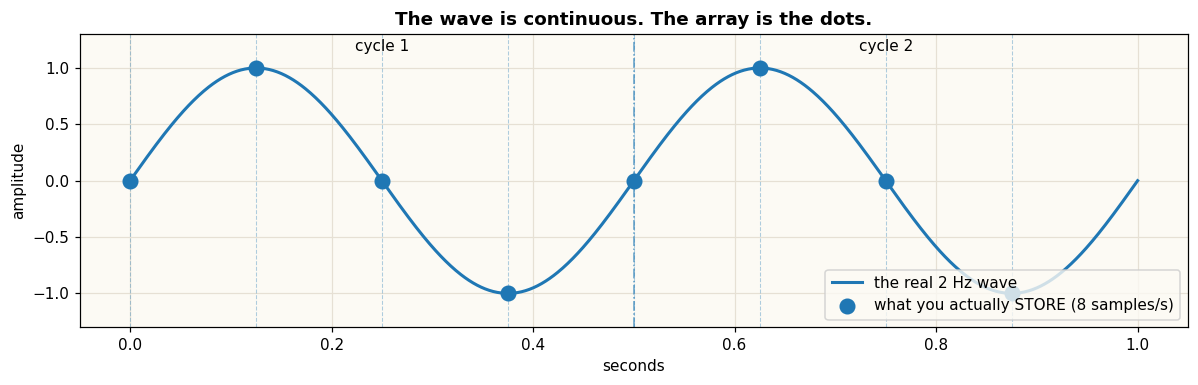

samples per cycle: 4.0
the array you'd store: [ 0.  1.  0. -1. -0.  1.  0. -1.]
time: 64.5 ms (started: 2026-08-25 11:06:06 +05:30)


In [7]:
sound_frequency = 2      # 2 cycles per second
sampling_rate   = 8      # 8 measurements per second

t_smooth  = np.linspace(0, 1.0, 1000)
y_smooth  = np.sin(2 * np.pi * sound_frequency * t_smooth)
t_samples = np.arange(0, 1.0, 1 / sampling_rate)
y_samples = np.sin(2 * np.pi * sound_frequency * t_samples)

plt.figure(figsize=(11, 3.6))
plt.plot(t_smooth, y_smooth, lw=2, label=f"the real {sound_frequency} Hz wave")
plt.scatter(t_samples, y_samples, s=90, zorder=3,
            label=f"what you actually STORE ({sampling_rate} samples/s)")
for tick in t_samples:
    plt.axvline(tick, ls="--", lw=0.7, alpha=0.35)
plt.axvline(0.5, ls="-.", lw=1, alpha=0.7)
plt.text(0.25, 1.15, "cycle 1", ha="center"); plt.text(0.75, 1.15, "cycle 2", ha="center")
plt.title("The wave is continuous. The array is the dots."); plt.xlabel("seconds")
plt.ylabel("amplitude"); plt.ylim(-1.3, 1.3); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("samples per cycle:", sampling_rate / sound_frequency)
print("the array you'd store:", np.round(y_samples, 2))

Now a real speech clip, so you can see that a recording really is just that —
a longer list of the same dots.

In [8]:
# A cached LibriSpeech clip. Decoded with soundfile (never torchcodec).
y16, sr0 = sf.read(CACHE / "librispeech_dummy.wav", dtype="float32")
ref_text = json.load(open(CACHE / "librispeech_dummy_meta.json"))["ref_text"]

print(f"samples  : {len(y16):,}   sr: {sr0} Hz   duration: {len(y16)/sr0:.2f}s")
print(f"dtype    : {y16.dtype}   range: [{y16.min():+.3f}, {y16.max():+.3f}]"
      "   <- floats in [-1, 1], which is what models want")
print(f"reference: {ref_text!r}")
display(Audio(y16, rate=SR))

samples  : 93,680   sr: 16000 Hz   duration: 5.86s
dtype    : float32   range: [-0.339, +0.388]   <- floats in [-1, 1], which is what models want
reference: 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL'


time: 2.05 ms (started: 2026-08-25 11:06:06 +05:30)


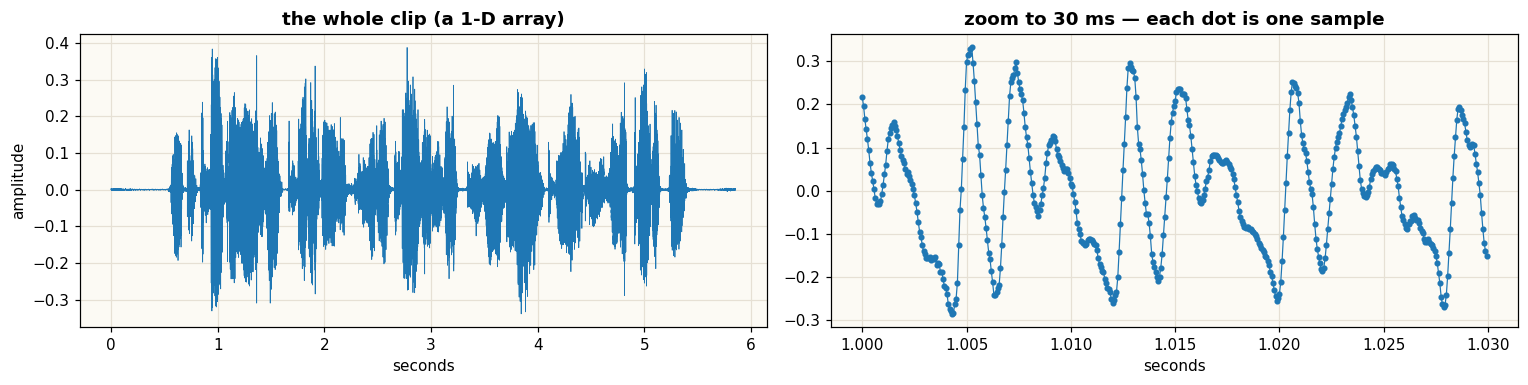

At 16000 Hz, 30 ms = 480 samples. The model reads all of them.
time: 108 ms (started: 2026-08-25 11:06:06 +05:30)


In [9]:
# Same array, two zoom levels. On the right each dot is ONE number in y16.
t = np.arange(len(y16)) / SR
a, b = int(1.00 * SR), int(1.03 * SR)          # a 30 ms window

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].plot(t, y16, lw=0.5)
ax[0].set(title="the whole clip (a 1-D array)", xlabel="seconds", ylabel="amplitude")
ax[1].plot(t[a:b], y16[a:b], "-o", ms=3, lw=0.8)
ax[1].set(title="zoom to 30 ms — each dot is one sample", xlabel="seconds")
plt.tight_layout(); plt.show()

print(f"At {SR} Hz, 30 ms = {int(0.03 * SR)} samples. The model reads all of them.")

#### 💡 Knowledge check
**Q1: A loader hands you a mono array of shape `(48000,)` for a clip you know is
exactly 3 seconds long. What sample rate was it recorded at?**

A) 8 kHz  B) 24 kHz  C) 16 kHz  D) 48 kHz

**Answer: C.** `samples / seconds = 48000 / 3 = 16000 Hz`. The array length alone
means nothing until you divide by the duration.

### These things are optional! Only go through if you want to get into more detail about how speech is represented and processed. Otherwise, skip to the next section.

`SPEECH ▸ ` P1 numbers ▸ **P2 frequencies** ▸ P3 footguns ▸ P4 Whisper ▸ P5 OpenAI `  ·  VISION ▸ ` P6 images ▸ P7 frames ▸ P8 +time ▸ P9 +transcript

## Part 2 · A real sound is many frequencies at once

Part 1 played you one frequency at a time. Nothing in the world sounds like that.

> **A real sound is many pure tones happening together** — different frequencies,
> different loudnesses, all added up into a single wave. A vowel, a guitar string,
> a car engine, a room full of people: each one is a sum of simple tones.

That is worth ten minutes because it explains what every speech model is actually
looking at. A model does not work on "the loudness at each instant" — that tells it
almost nothing. It works on **which frequencies are present, and how they change
over time.** The conversion from one to the other is a fixed, boring, solved piece
of maths that runs before the model and that you will never write yourself.

So: hear the sum, see the sum, and move on.

In [10]:
# Three pure tones -> a simple chord. Higher tones a little quieter, as in nature.
dur   = 1.5
t     = np.linspace(0, dur, int(SR * dur), endpoint=False)
freqs = [220.0, 440.0, 660.0]        # A3, A4, E5
amps  = [1.0, 0.5, 0.33]

tones = [a * np.sin(2 * np.pi * f * t) for f, a in zip(freqs, amps)]

for f, tone in zip(freqs, tones):
    print(f"{f:.0f} Hz on its own")
    display(Audio(0.3 * tone, rate=SR))

# Add them up. The sum is ONE array -- your ear hears a single richer sound,
# but there is no "three sounds" anywhere in the data. Just one list of numbers.
mix = np.sum(tones, axis=0)
mix = mix / np.max(np.abs(mix))          # normalise into [-1, 1] so it can't clip

print("all three, summed into one wave:")
display(Audio(0.3 * mix, rate=SR))

220 Hz on its own


440 Hz on its own


660 Hz on its own


all three, summed into one wave:


time: 4.48 ms (started: 2026-08-25 11:06:06 +05:30)


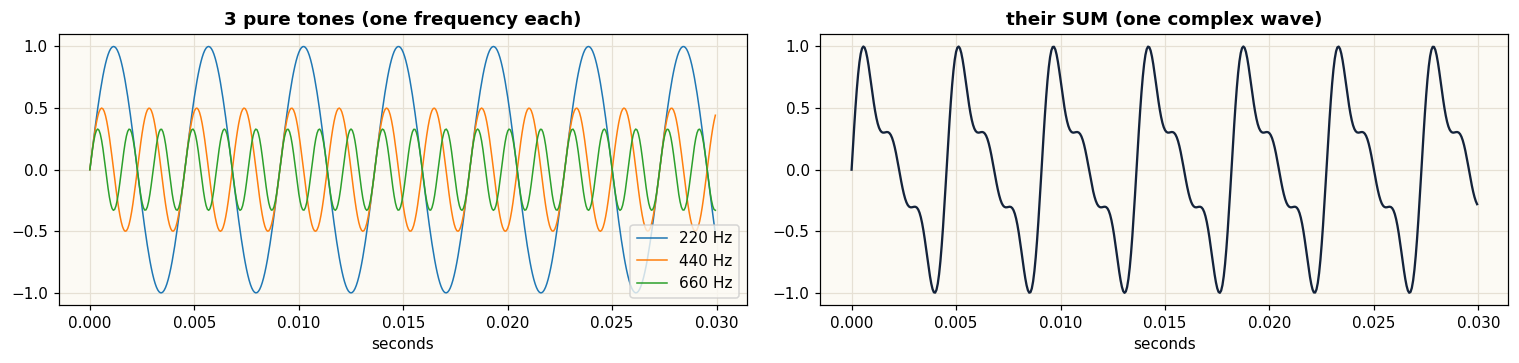

The right-hand wave is what a microphone records. Everything a speech model
does starts by pulling that shape back apart into its frequencies.
time: 93.3 ms (started: 2026-08-25 11:06:06 +05:30)


In [11]:
# Zoom in to 30 ms and look at what addition did to the shape.
a, b = 0, int(0.03 * SR)

fig, ax = plt.subplots(1, 2, figsize=(14, 3.4))
for f, tone in zip(freqs, tones):
    ax[0].plot(t[a:b], tone[a:b], lw=1, label=f"{f:.0f} Hz")
ax[0].set(title="3 pure tones (one frequency each)", xlabel="seconds"); ax[0].legend()
ax[1].plot(t[a:b], mix[a:b], color="#14233B", lw=1.5)
ax[1].set(title="their SUM (one complex wave)", xlabel="seconds")
plt.tight_layout(); plt.show()

print("The right-hand wave is what a microphone records. Everything a speech model")
print("does starts by pulling that shape back apart into its frequencies.")

`SPEECH ▸ ` P1 numbers ▸ P2 frequencies ▸ **P3 footguns** ▸ P4 Whisper ▸ P5 OpenAI `  ·  VISION ▸ ` P6 images ▸ P7 frames ▸ P8 +time ▸ P9 +transcript

## Part 3 · Getting the numbers right

Two ways to ruin the array before a model ever sees it. Both are silent.

### 3a · The Nyquist limit — why 16 kHz caps you at 8 kHz

How fast do you have to measure? One rule governs everything:

> **You need at least two samples per cycle of the highest frequency you want to
> keep.** So a sample rate `SR` can only faithfully capture frequencies up to
> `SR/2` — the **Nyquist limit**. 16 kHz speech → max 8 kHz. 44.1 kHz music →
> max 22 kHz. An 8 kHz phone line → max 4 kHz, which is exactly why phones sound
> like phones.

Fewer than two samples per cycle and the same dots *also fit a slower wave* — so
the fast tone gets mistaken for a slow one. That false low tone is **aliasing**.
Hear it:

In [12]:
# A 3 kHz tone is fine at 16 kHz (Nyquist 8 kHz). Sample the SAME tone at 4 kHz
# (Nyquist 2 kHz) by naively dropping samples -- 3 kHz folds down to
# |4000 - 3000| = 1000 Hz: a lower beep that was never played.
t_hi   = np.linspace(0, 1.5, int(SR * 1.5), endpoint=False)
tone3k = 0.3 * np.sin(2 * np.pi * 3000 * t_hi)

print("3000 Hz at the full 16 kHz rate (correct — a high beep):")
display(Audio(tone3k, rate=SR))

low_fs  = 4000
aliased = tone3k[:: SR // low_fs]          # naive drop = NO anti-alias filter
print(f"the same tone at {low_fs} Hz with no filter -> folds to "
      f"{abs(low_fs - 3000)} Hz (a LOWER beep that was never there):")
display(Audio(aliased, rate=low_fs))

3000 Hz at the full 16 kHz rate (correct — a high beep):


the same tone at 4000 Hz with no filter -> folds to 1000 Hz (a LOWER beep that was never there):


time: 2.2 ms (started: 2026-08-25 11:06:06 +05:30)


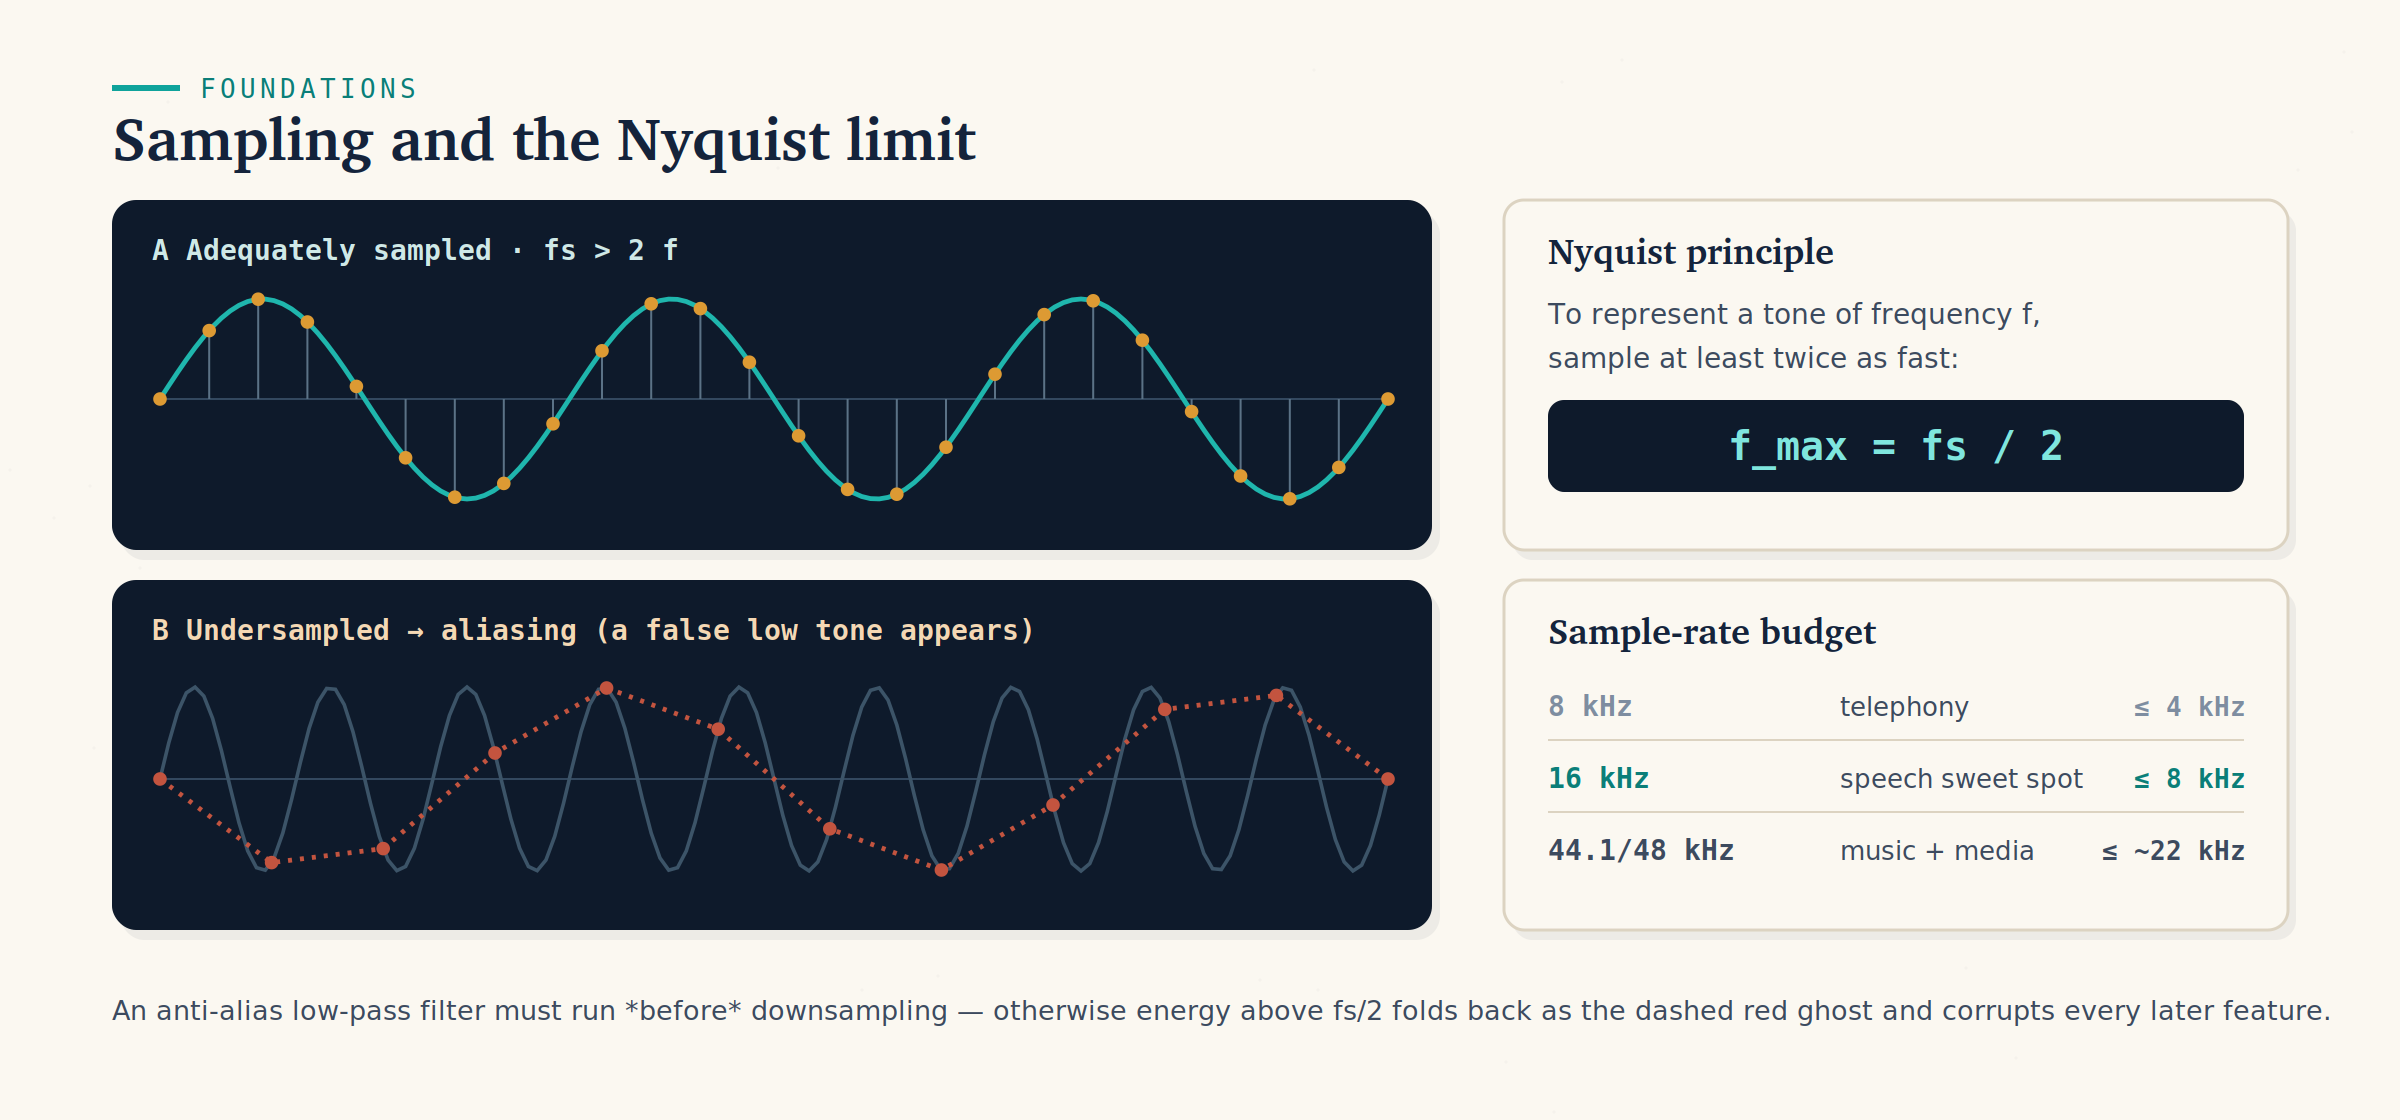
<sub><i>Enough samples reconstruct the tone; too few fold a high tone down into a permanent false low one (red). The fix is a low-pass filter <b>before</b> dropping samples — which is precisely what <code>librosa.resample</code> does for you, and what <code>y[::2]</code> does not.</i></sub>

**The practical consequence:** never downsample with `y[::2]`. Use
`librosa.resample`, which low-passes first. This is why "just take every other
sample" is a bug and not an optimisation.

#### 💡 Knowledge check
**Q2: A pure 5 kHz tone is sampled at 8 kHz with no anti-alias filter. What false
frequency do you hear?**

A) 1 kHz  B) 4 kHz  C) 5 kHz  D) 3 kHz

**Answer: D.** A tone above Nyquist folds to `|sample_rate − f| = |8000 − 5000| = 3000 Hz`.

### 3b · The five ways a loader silently corrupts your audio

In rough order of how often they bite:

1. **Sample-rate mismatch (the big one).** You load a 44.1 kHz podcast and pass
   `sampling_rate=16000` to the model. **Rule: resample to the model's rate AND
   pass that same rate everywhere.**
2. **Stereo vs mono.** Files arrive as `(samples, 2)`; models want `(samples,)`.
   *Average* the channels — don't just drop one.
3. **int16 vs float.** WAV stores `int16` in [−32768, 32767]; models want
   `float32` in [−1, 1]. `soundfile(dtype="float32")` handles it; `np.frombuffer` does not.
4. **Format / codec.** `.wav` is trivial; `.mp3/.m4a/.webm` need a decoder.
5. **Clipping.** Values outside [−1, 1] clip into harsh distortion.

Number 1 is worth *hearing*, because hearing it is what makes it stick.

In [13]:
# Our clip is 16 kHz. Lie to the player about its rate and listen to what a
# model would "read" if you passed the wrong sampling_rate=.
print("CORRECT — true rate,", SR, "Hz:")
display(Audio(y16, rate=SR))

print("'chipmunk' — claimed 24 kHz for 16 kHz audio (1.5x too fast):")
display(Audio(y16, rate=int(SR * 1.5)))

print("'slow-mo'  — claimed ~10.7 kHz (0.67x too slow):")
display(Audio(y16, rate=int(SR * 0.67)))

CORRECT — true rate, 16000 Hz:


'chipmunk' — claimed 24 kHz for 16 kHz audio (1.5x too fast):


'slow-mo'  — claimed ~10.7 kHz (0.67x too slow):


time: 3.66 ms (started: 2026-08-25 11:06:06 +05:30)


In [14]:
# The correct preparation, step by step, on a stereo 44.1 kHz file
# (which is how real audio actually arrives).
fake_sr = 44_100
stereo = np.stack([librosa.resample(y16, orig_sr=SR, target_sr=fake_sr)] * 2, axis=1)
print("arrived as :", stereo.shape, stereo.dtype, "@", fake_sr, "Hz")

mono = stereo.mean(axis=1).astype(np.float32)      # 1) stereo -> mono: AVERAGE
print("to mono    :", mono.shape, mono.dtype,
      "range [%.2f, %.2f]" % (mono.min(), mono.max()))

ready = librosa.resample(mono, orig_sr=fake_sr, target_sr=SR)   # 2) -> model's rate
print("to 16 kHz  :", ready.shape, "@", SR, "Hz   <- model-ready")

arrived as : (258206, 2) float32 @ 44100 Hz
to mono    : (258206,) float32 range [-0.35, 0.43]
to 16 kHz  : (93681,) @ 16000 Hz   <- model-ready
time: 1.39 s (started: 2026-08-25 11:06:06 +05:30)


#### 💡 Knowledge check
**Q3: All of these silently corrupt the audio a model sees, EXCEPT:**

A) Passing `sampling_rate=16000` for a 44.1 kHz file
B) Feeding a `(samples, 2)` stereo array to a mono model
C) Storing the waveform as float32 in [−1, 1]
D) Downsampling with `y[::2]` instead of a resampler

**Answer: C.** float32 in [−1, 1] is exactly what models expect. The other three
are the classic silent corruptions.

`SPEECH ▸ ` P1 numbers ▸ P2 frequencies ▸ P3 footguns ▸ **P4 Whisper** ▸ P5 OpenAI `  ·  VISION ▸ ` P6 images ▸ P7 frames ▸ P8 +time ▸ P9 +transcript

## Part 4 · Speech recognition with an open model

**Whisper** is the workhorse: a Transformer **encoder–decoder**.

It never sees your `float32` array directly. A fixed front-end first turns the
waveform into the frequencies-over-time picture from Part 2 — that is the
`(1, 80, 3000)` tensor you are about to print. **Treat that step as a black box
today**: it has no knobs you tune and no decisions you make. The encoder reads that
tensor; the decoder writes text one token at a time, attending back to it.

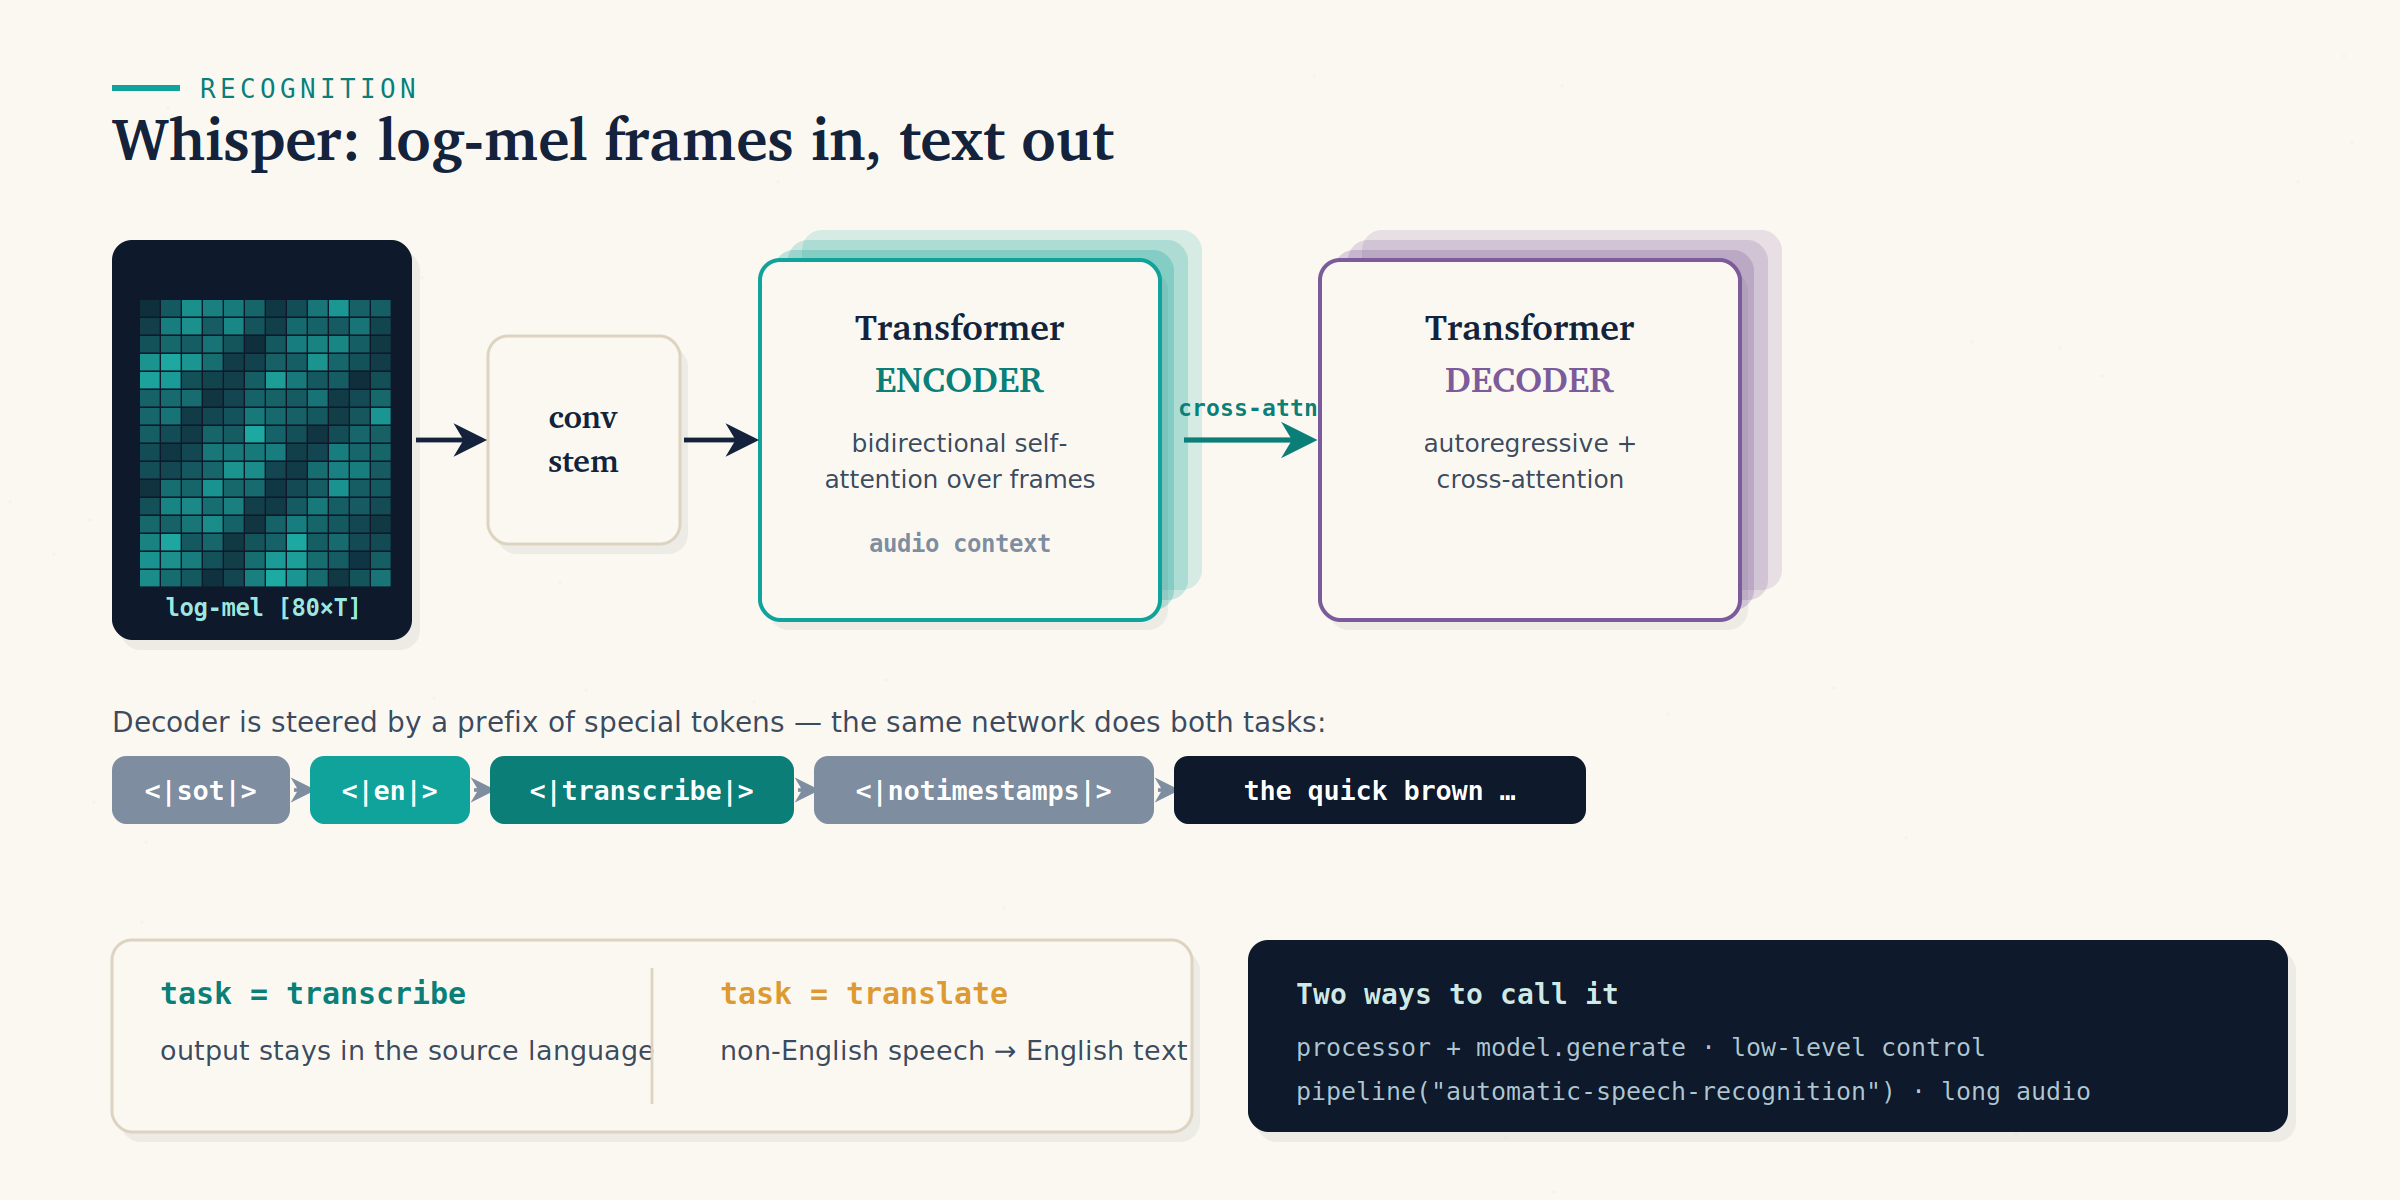
<sub><i>Encoder reads the 80-band log-mel; decoder emits text tokens. A special-token prefix steers the <b>same weights</b> between transcribe and translate.</i></sub>

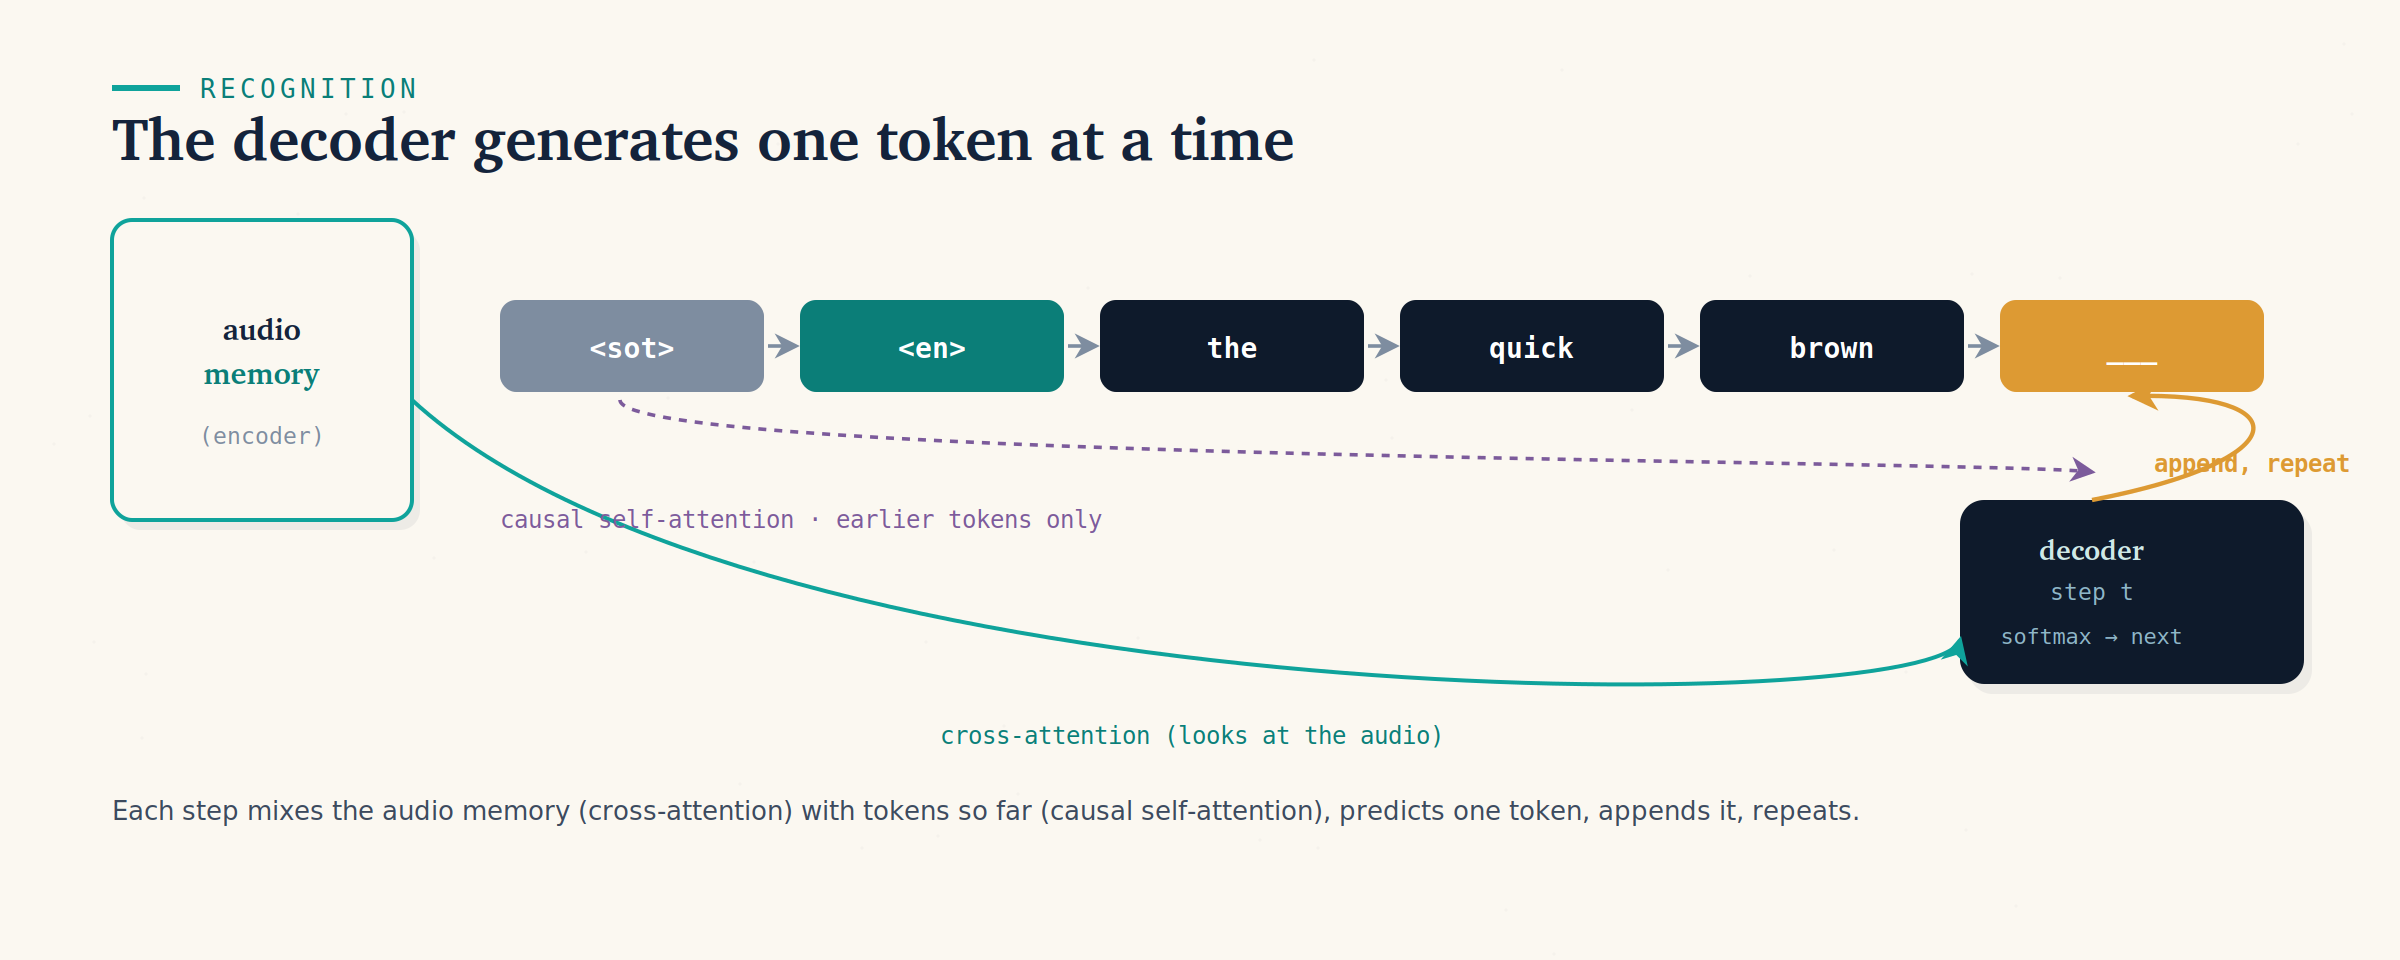
<sub><i>Autoregressive decoding: each step reads the audio (cross-attention) plus the tokens so far (causal self-attention), predicts the next token, appends, repeats.</i></sub>

The thing to internalise: **Whisper's task is set by a token prefix**, not by a
different model. `<|startoftranscript|><|en|><|transcribe|>` vs `…<|translate|>`
is the *only* difference between transcription and translation.

In [15]:
import transformers
from transformers import WhisperProcessor, WhisperForConditionalGeneration

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()   # HF's generation notices are noisy in class

processor = WhisperProcessor.from_pretrained(ASR_MODEL_ID)
model = WhisperForConditionalGeneration.from_pretrained(ASR_MODEL_ID).to(device).eval()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"loaded {ASR_MODEL_ID}  (~{n_params:.0f}M params) on {device}")

objc[97544]: Class AVFFrameReceiver is implemented in both /Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1113143a8) and /Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x12a6503a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[97544]: Class AVFAudioReceiver is implemented in both /Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1113143f8) and /Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x12a6503f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0).


W0825 11:06:11.098000 97544 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

loaded openai/whisper-base.en  (~73M params) on mps
time: 10.1 s (started: 2026-08-25 11:06:07 +05:30)


In [16]:
# NOTE sampling_rate=16_000. This MUST match the audio's true rate --
# it is the Part 3 footgun, made concrete right here.
feats = processor(y16, sampling_rate=SR, return_tensors="pt").input_features.to(device)
print("input_features:", tuple(feats.shape), "= (batch, 80 mel bands, frames)")

with torch.no_grad():
    ids = model.generate(feats, max_new_tokens=128)

hyp = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
print("\nhypothesis:", hyp)
print("reference :", ref_text)

input_features: (1, 80, 3000) = (batch, 80 mel bands, frames)



hypothesis: Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
reference : MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL
time: 343 ms (started: 2026-08-25 11:06:17 +05:30)


### The knobs you'll actually twist

| Knob | What it does | Production guidance |
|---|---|---|
| **model size** | `tiny` → `large-v3-turbo` | start at `large-v3-turbo`: near-`large` accuracy, ~6–8× faster. Use `*.en` models only for English. |
| **`language`** | skips auto-detect | **always set it if you know it.** Auto-detect fails often on short/noisy clips. |
| **`task`** | `transcribe` / `translate` | `translate` = speech → **English** text from any source language. |
| **`return_timestamps`** | per-segment times | needed for subtitles, diarization alignment, long audio (§4c). |
| **`temperature`** | sampling randomness | keep `0`. Whisper has a temperature *fallback* (0→0.2→…) for degenerate decodes. |
| **`condition_on_prev_tokens`** | feeds prior text as context | helps fluency but **propagates hallucinations** — off if you see runaway repeats. |

### ⚠️ Two failure modes that bite in production

1. **Hallucination on silence.** Fed silence, music or noise, Whisper confidently
   emits training-data priors — *"Thank you."*, *"Thanks for watching!"*, *"♪"*,
   subtitle credits. It learned those from YouTube-style data.
2. **Repetition loops.** On long silences the decoder can get stuck repeating a
   phrase forever.

The single highest-impact fix for both is the next section: **don't send it
non-speech in the first place.**

### 4a · VAD — find the speech before you transcribe

Voice Activity Detection answers "*where* is there speech?" It is cheap, fast,
and the standard pre-filter. **Silero VAD** is the production default: tiny,
MIT-licensed, CPU-only. Energy/RMS heuristics are not good enough on real audio —
use a learned VAD.

> 🔧 **Gotcha:** `silero-vad` imports **`torchaudio`** internally. Without it you
> get a bare `ModuleNotFoundError` from `torch.hub.load` that never mentions
> torchaudio. `pip install torchaudio` matching your torch version.

In [17]:
vad_model, vad_utils = torch.hub.load("snakers4/silero-vad", "silero_vad",
                                      trust_repo=True)
get_speech_timestamps = vad_utils[0]

# Silero wants 16 kHz mono float32 as a torch tensor.
speech = get_speech_timestamps(torch.from_numpy(np.ascontiguousarray(y16)),
                               vad_model, sampling_rate=SR, return_seconds=True)

print(f"clip is {len(y16)/SR:.2f}s long; VAD found {len(speech)} speech segment(s):")
for s in speech:
    print(f"  speech {s['start']:.2f}s -> {s['end']:.2f}s")

clip is 5.86s long; VAD found 1 speech segment(s):
  speech 0.50s -> 5.50s
time: 356 ms (started: 2026-08-25 11:06:18 +05:30)


Using cache found in /Users/shivam13juna/.cache/torch/hub/snakers4_silero-vad_master


In [18]:
# Keep only what the VAD marked as speech. On a real recording this is what you
# hand to Whisper -- the silence it never sees is silence it can't hallucinate on.
speech_only = np.concatenate([y16[int(s["start"] * SR):int(s["end"] * SR)]
                              for s in speech])

print(f"original    : {len(y16)/SR:.2f}s")
display(Audio(y16, rate=SR))
print(f"speech only : {len(speech_only)/SR:.2f}s "
      f"({100 * (1 - len(speech_only)/len(y16)):.0f}% dropped)")
display(Audio(speech_only, rate=SR))

original    : 5.86s


speech only : 5.00s (15% dropped)


time: 2.98 ms (started: 2026-08-25 11:06:18 +05:30)


#### 💡 Knowledge check
**Q4: What most effectively stops Whisper transcribing "Thank you for watching"
over a silent stretch?**

A) Use a larger model like large-v3
B) Increase the sample rate to 48 kHz
C) VAD-gate the audio and skip non-speech segments
D) Switch from float32 to int16

**Answer: C.** A bigger model hallucinates more fluently, not less. Don't feed it
the silence.

### 4b · Score it properly — Word Error Rate

ASR is **not** scored like text generation. **WER** counts edits:

```
WER = (substitutions + insertions + deletions) / reference_words
```

computed *after* normalising case and punctuation — otherwise you are measuring
formatting, not recognition. A toy example first, so the number is concrete.

In [19]:
from jiwer import wer

_ref = "the quick brown fox jumps over the lazy dog"
_hyp = "the quick brown fox jump over lazy dog"       # 1 substitution + 1 deletion

print("reference :", _ref)
print("hypothesis:", _hyp)
print(f"WER       : {wer(_ref, _hyp):.3f}   (2 errors / 9 reference words)")

reference : the quick brown fox jumps over the lazy dog
hypothesis: the quick brown fox jump over lazy dog
WER       : 0.222   (2 errors / 9 reference words)
time: 52.7 ms (started: 2026-08-25 11:06:18 +05:30)


In [20]:
# Real WER on the Whisper output. Normalise BOTH sides first: the reference is
# shouty LibriSpeech ("MISTER"), Whisper writes real English ("Mr."). That is a
# formatting difference, not a recognition error, and WER can't tell them apart.
# EnglishTextNormalizer is the one Whisper's own paper reports against -- it
# lowercases, strips punctuation AND expands abbreviations. (For non-English,
# BasicTextNormalizer from the same module does the language-agnostic subset.)
from transformers.models.whisper.english_normalizer import EnglishTextNormalizer
norm = EnglishTextNormalizer({})

print("reference  (norm):", norm(ref_text))
print("hypothesis (norm):", norm(hyp))
print(f"\nWER raw        : {wer(ref_text.lower(), hyp.lower()):.3f}")
print(f"WER normalized : {wer(norm(ref_text), norm(hyp)):.3f}   <- report THIS one")

reference  (norm): mister quilter is the apostle of the middle classes and we are glad to welcome his gospel
hypothesis (norm): mister quilter is the apostle of the middle classes and we are glad to welcome his gospel

WER raw        : 0.176
WER normalized : 0.000   <- report THIS one
time: 2.87 ms (started: 2026-08-25 11:06:18 +05:30)


Same transcript, two very different numbers. Raw WER says this 73M-parameter model
got ~18% of the words wrong; it did not — it got **every word right** and wrote
them the way a human would. Report the normalised number, and say which normaliser
you used, or your WER is not comparable to anyone else's.

#### 💡 Knowledge check
**Q5: A reference sentence has 20 words. Whisper's output has 1 substitution,
2 deletions and 1 insertion. What is the WER?**

A) 5%  B) 15%  C) 20%  D) 25%

**Answer: C.** `(1 + 2 + 1) / 20 = 0.20`. Insertions count too — which is why WER
can exceed 100%.

### 4c · Long audio — Whisper only ever sees 30 seconds

Whisper's encoder takes a fixed **30-second** window; that is how it was trained.
Anything longer must be split, and a naive split cuts words in half at the seams.
The standard answer is **30 s chunks with a ~5 s overlap**, then de-duplicate the
overlap.

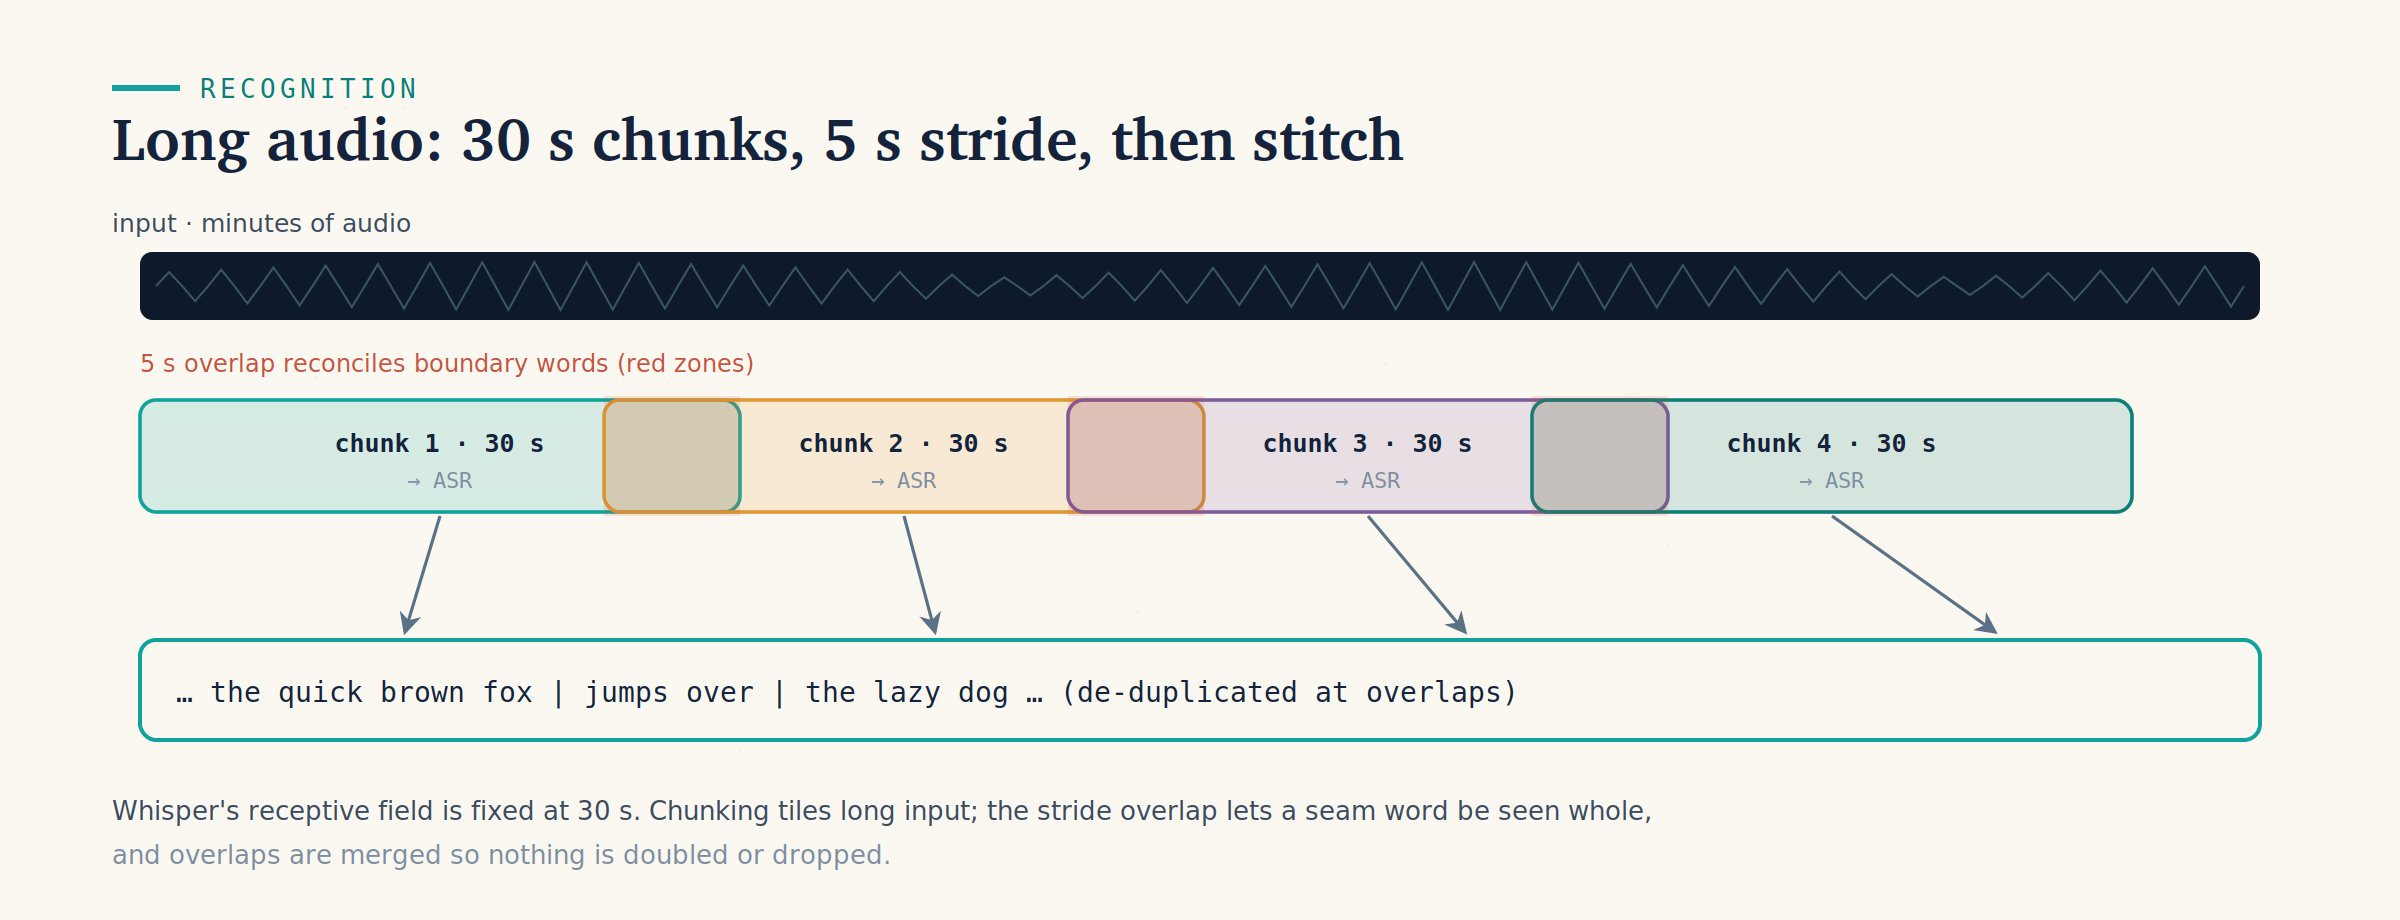
<sub><i>30 s chunks with a 5 s stride; the overlapping regions (red) are reconciled into one continuous, de-duplicated transcript.</i></sub>

Transformers does this for you inside `generate()` — pass the **whole** clip with
`truncation=False, padding="longest"` and it runs Whisper's own sequential
long-form algorithm, handing back per-segment timestamps.

> 🔧 **Gotcha:** the older recipe for this was
> `pipeline(..., chunk_length_s=30, stride_length_s=5)`. On `transformers` 5.x
> that pipeline pulls in **`torchcodec`**, which needs system ffmpeg libraries and
> dies with `Could not load libtorchcodec` on plenty of machines (including this
> one). `model.generate()` is both the supported path now and the one that
> actually runs.

In [21]:
# A genuinely long clip: 62 s of LibriSpeech, well past the 30 s window.
y_long, _ = sf.read(CACHE / "librispeech_long.wav", dtype="float32")
print(f"clip: {len(y_long)/SR:.1f}s  (> 30 s, so it must be chunked)")

# truncation=False + padding="longest" = "do NOT cut me to 30 s; chunk me."
inputs = processor(y_long, sampling_rate=SR, return_tensors="pt",
                   truncation=False, padding="longest", return_attention_mask=True)
print("input_features:", tuple(inputs.input_features.shape),
      "  <- 3000 frames would be 30 s; this is longer\n")

with torch.no_grad():
    out = model.generate(inputs.input_features.to(device),
                         attention_mask=inputs.attention_mask.to(device),
                         return_timestamps=True, return_segments=True)

for seg in out["segments"][0]:
    text = processor.decode(seg["tokens"], skip_special_tokens=True).strip()
    print(f"[{float(seg['start']):6.2f}s -> {float(seg['end']):6.2f}s] {text}")

clip: 62.5s  (> 30 s, so it must be chunked)
input_features: (1, 80, 6245)   <- 3000 frames would be 30 s; this is longer



[  0.00s ->   6.56s] Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
[  6.56s ->  11.28s] Nor is Mr. Quilter's manner less interesting than his matter.
[ 11.28s ->  16.84s] He tells us that at this festive season of the year, with Christmas and roast beef looming
[ 16.84s ->  23.78s] before us, similes drawn from eating and its results occur most readily to the mind.
[ 23.78s ->  29.46s] He has grave doubts whether Sir Frederick Layton's work is really Greek after all, and
[ 29.46s ->  33.66s] can discover in it but little of rocky Ithaca.
[ 33.66s ->  39.78s] Lynille's pictures are a sort of up-gards and atom paintings, and Mason's exquisite
[ 39.78s ->  44.62s] idols are as national as a jingo poem.
[ 44.62s ->  50.14s] Mr. Burkett Foster's landscapes smile at one much in the same way that Mr. Carkerer
[ 50.14s ->  52.90s] used to flash his teeth.
[ 52.90s ->  59.46s] Mr. John Collier gives his sitter a cheerful slap on the back before he says

Look at where the segment boundaries land: they do **not** stop at 30.00 s. The
chunks overlap and get stitched, so a word sitting on a seam survives.

#### 💡 Knowledge check
**Q6: You are transcribing a 5-minute podcast in 30 s chunks. Why overlap them by
5 s instead of cutting cleanly?**

A) It shortens each window to save memory
B) It makes Whisper emit a timestamp every 5 seconds
C) A word on a chunk boundary is still seen whole by the neighbouring chunk
D) It limits the audio to five speakers

**Answer: C.** Clean 30 s cuts slice words in half; the overlap lets a boundary
word appear intact in one of the two chunks, and the duplicate is then dropped.

### One more production reality: "who spoke when?"

Whisper transcribes *what* was said, not *who* said it. For meetings and calls you
add a **diarization** model — `pyannote.audio` is the standard — and align its
speaker turns against Whisper's timestamps.

`SPEECH ▸ ` P1 numbers ▸ P2 frequencies ▸ P3 footguns ▸ P4 Whisper ▸ **P5 OpenAI** `  ·  VISION ▸ ` P6 images ▸ P7 frames ▸ P8 +time ▸ P9 +transcript

## Part 5 · The same two jobs, through the OpenAI API

Everything in Part 4 you hosted yourself. Here is the managed version: one REST
call each way. No GPU, no model download, no 30-second window to think about —
you pay per minute instead, and the audio leaves your box.

Docs: <https://platform.openai.com/docs/guides/speech-to-text> ·
<https://platform.openai.com/docs/guides/text-to-speech>

In [22]:
# --- speech -> text --------------------------------------------------------
with open("test_audio.wav", "rb") as audio_file:
    transcription = client.audio.transcriptions.create(
        model=OPENAI_ASR,
        file=audio_file,
    )

print("transcribed:", transcription.text)

# Audio is billed as TOKENS too -- and they are input tokens, like any prompt.
u = transcription.usage
print("\ninput tokens :", u.input_tokens, " of which audio:",
      u.input_token_details.audio_tokens)
print("output tokens:", u.output_tokens, "| total:", u.total_tokens)

transcribed: Hello, testing one two three

input tokens : 34  of which audio: 34
output tokens: 8 | total: 42
time: 982 ms (started: 2026-08-25 11:06:21 +05:30)


In [23]:
# --- the one knob worth knowing: prompt= -----------------------------------
# It is NOT an instruction. It is a text hint that biases the decoder toward
# your vocabulary -- product names, acronyms, jargon, spelling conventions.
with open("test_audio.wav", "rb") as audio_file:
    guided = client.audio.transcriptions.create(
        model=OPENAI_ASR,
        file=audio_file,
        prompt="This is a simple English test recording. Please transcribe it accurately.",
    )

print("without prompt:", transcription.text)
print("with prompt   :", guided.text)
print("\ninput tokens  :", transcription.usage.input_tokens, "->",
      guided.usage.input_tokens, " (the hint is billed as text tokens)")

without prompt: Hello, testing one two three
with prompt   : Hello testing one two three.

input tokens  : 34 -> 47  (the hint is billed as text tokens)
time: 1.24 s (started: 2026-08-25 11:06:22 +05:30)


Look at what changed — and at what didn't. The **words** are identical; what moved is
the **formatting**: punctuation, capitalisation, and whether numbers come out as
`one two three` or `123`. Nobody asked for any of that.

Run the cell three or four times in class. It lands differently each time, and not
always in the direction the hint suggests — I have seen the hinted call produce
*both* spellings on different runs. That instability is the lesson, not a glitch.

`prompt=` is not an instruction the model obeys. It is text prepended to the decode
that **biases** what comes out, style included. Feed it vocabulary the model would
otherwise mangle (product names, drug names, ticker symbols, "Kubernetes", your CEO's
surname) and it earns its keep. Give it orders and you will get surprised. **Always
diff before/after on your own audio before you ship it.**

In [24]:
# --- text -> speech --------------------------------------------------------
speech_file_path = Path("tutor_voice.mp3")

with client.audio.speech.with_streaming_response.create(
    model=OPENAI_TTS,
    voice="nova",                      # alloy, echo, fable, onyx, nova, shimmer
    input="Hello students! Today we will explore AI that can see, listen, and speak."
) as response:
    response.stream_to_file(speech_file_path)

print("saved:", speech_file_path, f"({speech_file_path.stat().st_size/1024:.0f} KB)")
display(Audio(str(speech_file_path)))

saved: tutor_voice.mp3 (81 KB)


time: 2.34 s (started: 2026-08-25 11:06:23 +05:30)


### Local or managed?

| | **Run Whisper yourself (Part 4)** | **Call the API (Part 5)** |
|---|---|---|
| Cost | your GPU, zero marginal | per minute of audio |
| Privacy | audio never leaves the box | audio goes to a vendor |
| Control | every knob, any fine-tune | the knobs they expose |
| Ops | you own scaling, batching, cold starts | none |
| Extras | you build VAD/diarization/timestamps | often bundled |

Choose by **latency, cost at your volume, and privacy** — not by default. High
volume and steady load favours self-hosting; spiky, low volume favours the API.

> 🔧 **The one that catches people:** `gpt-4o-transcribe` does **not** return
> segment timestamps. If you need them (subtitles, alignment, the video half of
> this class), use `whisper-1` with `response_format="verbose_json"`. That is why
> the config cell has both.

`SPEECH ▸ ` P1 numbers ▸ P2 frequencies ▸ P3 footguns ▸ P4 Whisper ▸ P5 OpenAI `  ·  VISION ▸ ` **P6 images** ▸ P7 frames ▸ P8 +time ▸ P9 +transcript

## Part 6 · How do you send an image?

Video is going to turn out to be "a few images plus timestamps", so images come
first. There are exactly three things to know.

1. **You send a URL or base64 bytes.** Nothing else. There is no "image object".
2. **You pay per image-token**, and `detail` is the dial that sets how many.
3. The **Responses API** spells it slightly differently from Chat Completions —
   same idea, different key names.

Docs: <https://developers.openai.com/api/docs/guides/images-vision>

In [25]:
# --- 1) an image by URL, cheap setting -------------------------------------
IMAGE_URL = "https://www.animesenpai.net/wp-content/uploads/2023/12/sef-min.png.webp"

vision_response = client.chat.completions.create(
    model=VISION_MODEL,
    messages=[
        {"role": "system",
         "content": "You are an art critic who gives gentle feedback on illustrations."},
        {"role": "user", "content": [
            {"type": "text", "text": "Analyze this illustration in 3 sentences."},
            {"type": "image_url", "image_url": {
                "url": IMAGE_URL,
                "detail": "low",          # "low" | "high" | "auto"
            }},
        ]},
    ],
)

pretty_print("=== detail='low' ===")
pretty_print(vision_response.choices[0].message.content)
print("\nprompt tokens:", vision_response.usage.prompt_tokens)

=== detail='low' ===
This illustration presents a towering, demon-like figure with an exposed ribcage
and taut, sculpted musculature, rendered in cool, desaturated blues that feel
otherworldly. A smoky, shadow-soaked environment and strong backlighting sculpt
the silhouette, giving the creature a menacing, statue-like presence. Its
elongated limbs, curling tail, and blade-like protrusions create a dynamic,
predatory silhouette; a touch more color variation or edge distinction could
help separate form from background and guide the eye to a focal point.

prompt tokens: 820
time: 6.15 s (started: 2026-08-25 11:06:26 +05:30)


In [26]:
# --- 2) what does `detail` actually cost? ----------------------------------
# Same image, same question, four ways. Only the PROMPT tokens matter here.
for model in ["gpt-4o-mini", VISION_MODEL]:
    for detail in ["low", "high"]:
        r = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": [
                {"type": "text", "text": "One word: what is this?"},
                {"type": "image_url", "image_url": {"url": IMAGE_URL, "detail": detail}},
            ]}],
        )
        print(f"{model:12}  detail={detail:5}  ->  prompt tokens: {r.usage.prompt_tokens:>7,}")

gpt-4o-mini   detail=low    ->  prompt tokens:   2,847


gpt-4o-mini   detail=high   ->  prompt tokens:  25,515


gpt-5-nano    detail=low    ->  prompt tokens:     803


gpt-5-nano    detail=high   ->  prompt tokens:     803
time: 12.8 s (started: 2026-08-25 11:06:32 +05:30)


Two different lessons in those four numbers.

**On `gpt-4o-mini`, `detail` is the whole ball game — roughly 9× here.** `low` means
"resize it to a thumbnail": a flat token cost, plenty for *gist* — scene, action,
mood, is-there-a-cat. `high` tiles the image into 512-px squares and bills every
tile, so the cost scales with resolution. Pay for `high` only when you need to
**read** something: small text, a UI, a licence plate, a chart.

**On `gpt-5-nano` the two numbers are identical — `detail` does nothing.** The GPT-5
family doesn't tile; it cuts the image into fixed 32-px patches and counts those, so
the parameter is silently ignored. It is not an error and nothing warns you.

The transferable lesson is the ugly one: **image pricing is per model family, and the
knob you read about in a blog post may be a no-op on the model you actually called.**
Print `usage` on your real model with your real images before you promise anyone a
cost estimate. In Part 7 whatever that per-image number is gets multiplied by the
number of frames.

In [27]:
# --- 3) a LOCAL file: base64 data URL --------------------------------------
# This is the form video frames will use, because a frame in memory has no URL.
with open("fluffy.jpeg", "rb") as f:
    b64 = base64.standard_b64encode(f.read()).decode("utf-8")

print("data URL length:", len(b64), "characters of base64")

local_response = client.chat.completions.create(
    model=VISION_MODEL,
    messages=[{"role": "user", "content": [
        {"type": "text", "text": "What animal is this, and what is it doing?"},
        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}",
                                            "detail": "low"}},
    ]}],
)

pretty_print(local_response.choices[0].message.content)

data URL length: 78264 characters of base64


A golden retriever puppy, and it’s sitting calmly.
time: 2.68 s (started: 2026-08-25 11:06:44 +05:30)


In [28]:
# --- 4) the same call in the RESPONSES API ---------------------------------
# Different key names, identical idea:
#   messages   -> input          system -> instructions
#   image_url  -> input_image    text   -> input_text
response_vision = client.responses.create(
    model=VISION_MODEL,
    instructions="You are an art critic who gives gentle feedback on illustrations.",
    input=[{"role": "user", "content": [
        {"type": "input_text", "text": "Analyze this illustration in 3 sentences."},
        {"type": "input_image",
         "image_url": "https://www.animesenpai.net/wp-content/uploads/2023/12/sef-min.png.webp",
         "detail": "low"},
    ]}],
)

pretty_print("=== Responses API ===")
pretty_print(response_vision.output_text)
print("\ninput tokens:", response_vision.usage.input_tokens,
      "| output tokens:", response_vision.usage.output_tokens)

=== Responses API ===
The creature’s anatomy is stylized and exaggerated, with a ribcagelike torso and
clawed hands that anchor its formidable presence. The cool desaturated palette
of pale blues and grays against the smoky, dark background heightens the eerie
mood and emphasizes the sculpture-like forms. The dynamic pose, with broad
shoulders and a sweeping tail, creates a strong diagonal flow that guides the
eye and hints at imminent action.

input tokens: 821 | output tokens: 580
time: 7.01 s (started: 2026-08-25 11:06:47 +05:30)


`SPEECH ▸ ` P1 numbers ▸ P2 frequencies ▸ P3 footguns ▸ P4 Whisper ▸ P5 OpenAI `  ·  VISION ▸ ` P6 images ▸ **P7 frames** ▸ P8 +time ▸ P9 +transcript

## Part 7 · A video is just frames you chose

Strip the container away and a clip is `frames × H × W × 3`: a stack of images
indexed by time. Two facts decide everything you do next.

- **Raw size is linear in length.** 10 minutes of 1080p at 30 fps is ~112 GB as
  raw `uint8`. You never hold that, and you certainly never send it.
- **What you pay for is tokens.** Every frame you send becomes image-tokens (Part 6).

So the first question is never "how big is the file". It is:

> **How few frames can I get away with?**

> 🔧 **Gotcha:** `CAP_PROP_FRAME_COUNT` *lies.* For variable-frame-rate clips it is
> an estimate, and `frame_count / fps` can be off by seconds. If exact timing
> matters, trust decoded timestamps instead.

In [29]:
# Read metadata WITHOUT decoding a single frame (cheap).
cap      = cv2.VideoCapture(VIDEO_PATH)
fps      = cap.get(cv2.CAP_PROP_FPS) or 25.0
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
H        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
W        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
cap.release()

print(f"shape (T,H,W,C) : ({n_frames}, {H}, {W}, 3)")
print(f"fps / duration  : {fps:.2f} fps  /  {n_frames/fps:.1f} s")
print(f"raw decoded RGB : {n_frames * H * W * 3 / 1e6:,.0f} MB in memory")

# The translation that actually drives every decision: frames -> tokens -> dollars.
TOK_PER_HIGH_FRAME = 765          # ~a 1024px frame at detail="high"
PRICE_PER_1M_INPUT = 2.50         # illustrative $ / 1M input tokens -- CHECK CURRENT PRICING
tok_all = n_frames * TOK_PER_HIGH_FRAME

print(f"\nif you naively sent EVERY frame at high detail:")
print(f"  {n_frames} frames x {TOK_PER_HIGH_FRAME} tok = {tok_all:,} image-tokens")
print(f"  ~= {tok_all/128_000:.1f}x a 128k context window, "
      f"~${tok_all/1e6*PRICE_PER_1M_INPUT:,.2f} per call")
print("  -> impossible. The whole game is sampling FEW frames well.")

shape (T,H,W,C) : (2624, 720, 1280, 3)
fps / duration  : 29.97 fps  /  87.6 s
raw decoded RGB : 7,255 MB in memory

if you naively sent EVERY frame at high detail:
  2624 frames x 765 tok = 2,007,360 image-tokens
  ~= 15.7x a 128k context window, ~$5.02 per call
  -> impossible. The whole game is sampling FEW frames well.
time: 12.2 ms (started: 2026-08-25 11:06:54 +05:30)


### The two knobs, and why sampling is safe

| Knob | Trades | Sensible default |
|---|---|---|
| **# frames** | coverage ↔ tokens/$ | ~1 frame/sec, capped at 8–32 total |
| **resolution** | detail (OCR, small objects) ↔ tokens/$ | longest side ≤ 512–768 px |

Sampling is safe because consecutive frames are near-duplicates — at 30 fps you
would pay 30× for the same information. Below: decode the clip once, keep only
the frames we actually want, and shrink them on the way in.

In [30]:
NUM_FRAMES, MAX_SIDE = 12, 512

# Which frame indices do we want? Uniformly spaced across the whole clip.
wanted = set(np.linspace(0, n_frames - 1, NUM_FRAMES).round().astype(int).tolist())

cap = cv2.VideoCapture(VIDEO_PATH)
frames, stamps, i = [], [], 0
while True:
    ok, bgr = cap.read()               # decode SEQUENTIALLY -- seeking lies on some codecs
    if not ok:
        break
    if i in wanted:
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)      # GOTCHA: OpenCV decodes BGR!
        h, w = rgb.shape[:2]
        scale = min(1.0, MAX_SIDE / max(h, w))          # shrink only, never upscale
        if scale < 1.0:
            rgb = cv2.resize(rgb, (int(w * scale), int(h * scale)))
        frames.append(rgb)
        stamps.append(i / fps)                          # REMEMBER WHEN -- Part 8 needs it
    i += 1
cap.release()

print(f"decoded {i} frames, kept {len(frames)}")
print(f"timestamps (s): {[round(t, 1) for t in stamps]}")
print(f"frame shape after resize: {frames[0].shape}")

decoded 2624 frames, kept 12
timestamps (s): [0.0, 7.9, 15.9, 23.9, 31.8, 39.8, 47.7, 55.7, 63.7, 71.6, 79.6, 87.5]
frame shape after resize: (288, 512, 3)
time: 1.64 s (started: 2026-08-25 11:06:54 +05:30)


In [31]:
# A frame in memory has no URL, so it goes over the wire as base64 -- exactly the
# form you built by hand in Part 6. JPEG (not PNG): ~10x smaller for photos, and
# quality=80 is invisible to a vision model.
def frame_to_data_url(rgb, quality=80):
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)          # imencode wants BGR back
    ok, buf = cv2.imencode(".jpg", bgr, [cv2.IMWRITE_JPEG_QUALITY, quality])
    return "data:image/jpeg;base64," + base64.b64encode(buf).decode("ascii")


sent_mb = sum(len(frame_to_data_url(f)) for f in frames) / 1e6
raw_mb  = n_frames * H * W * 3 / 1e6
print(f"raw decoded clip : {raw_mb:8.1f} MB")
print(f"what you send    : {sent_mb:8.2f} MB   ({raw_mb/sent_mb:.0f}x smaller)")

raw decoded clip :   7254.8 MB
what you send    :     0.26 MB   (28216x smaller)
time: 4.04 ms (started: 2026-08-25 11:06:56 +05:30)


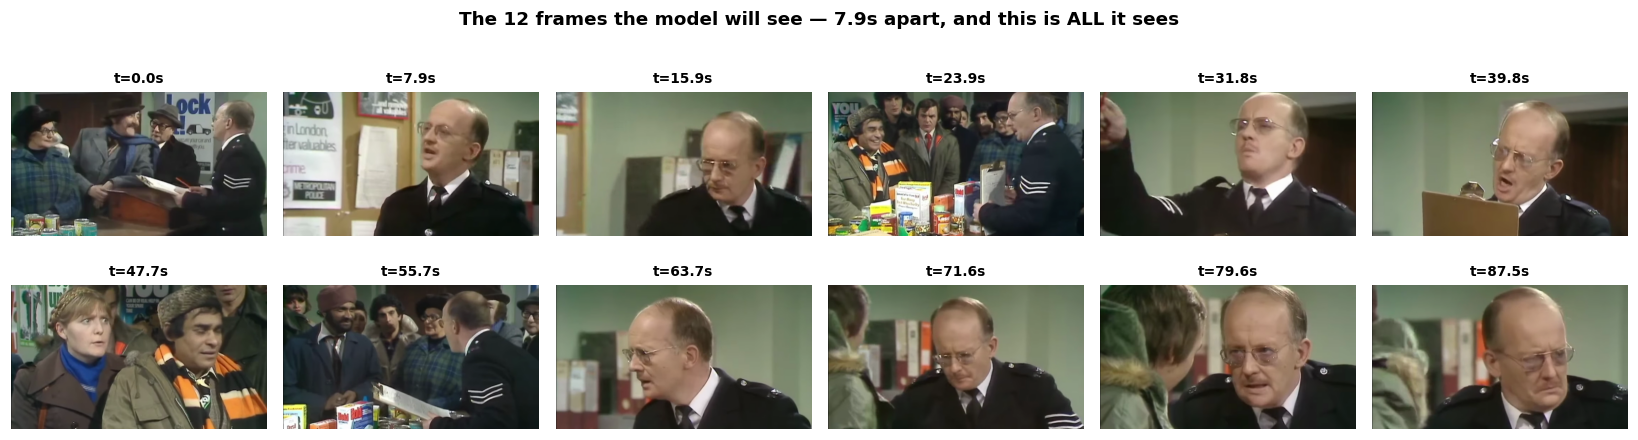

time: 190 ms (started: 2026-08-25 11:06:56 +05:30)


In [32]:
# Look at exactly what the model will receive. Nothing else -- no motion,
# no audio, no order, unless you say so.
fig, ax = plt.subplots(2, 6, figsize=(15, 4.4))
for a in ax.ravel():
    a.axis("off")
for a, f, t in zip(ax.ravel(), frames, stamps):
    a.imshow(f); a.set_title(f"t={t:.1f}s", fontsize=9)
fig.suptitle(f"The {len(frames)} frames the model will see — {stamps[1]-stamps[0]:.1f}s apart, "
             "and this is ALL it sees", fontweight="bold")
fig.tight_layout(); plt.show()

> 🔧 **Decode gotchas that bite real pipelines:**
> - **BGR vs RGB.** OpenCV decodes **BGR**. Forget the `cvtColor` and reds and blues
>   swap — the model will cheerfully describe the wrong scene.
> - **Rotation metadata.** Phone videos store a rotation flag that some decoders
>   ignore, so portrait clips arrive **sideways**. Check
>   `cap.get(cv2.CAP_PROP_ORIENTATION_META)`, or decode with PyAV/ffmpeg.
> - **Variable frame rate.** Screen recordings vary fps, so `frame_index / fps`
>   slowly **drifts** out of sync. Read per-frame PTS (PyAV) if timing matters.
> - **Decoding is the silent cost.** It is CPU-bound and usually the slowest stage
>   at scale. Cache extracted frames; use decord or PyAV, not an OpenCV Python loop.

`SPEECH ▸ ` P1 numbers ▸ P2 frequencies ▸ P3 footguns ▸ P4 Whisper ▸ P5 OpenAI `  ·  VISION ▸ ` P6 images ▸ P7 frames ▸ **P8 +time** ▸ P9 +transcript

## Part 8 · Frames + timestamps → the model

Here is the move that separates a toy call from a working one.

> A vision model receives an **unordered bag of images**. It does not know they
> came from one video, it does not know the order, and it certainly does not know
> *when* each one happened.

So you tell it: interleave a tiny text label **before** each frame. Suddenly it can
reason about before/after and cite moments back to you.

In [33]:
content = [{"type": "text",
            "text": ("These are frames sampled IN ORDER from one short video; each is "
                     "labeled with its timestamp. Reason about what happens over time.")}]

for t, f in zip(stamps, frames):
    content.append({"type": "text", "text": f"[frame @ {t:.1f}s]"})      # order + time
    content.append({"type": "image_url",
                    "image_url": {"url": frame_to_data_url(f), "detail": "low"}})

content.append({"type": "text",
                "text": "In 2-3 sentences, describe what happens across the clip."})

print(f"message has {len(content)} parts: 1 preamble + "
      f"{len(frames)} labels + {len(frames)} images + 1 question")

message has 26 parts: 1 preamble + 12 labels + 12 images + 1 question
time: 4.03 ms (started: 2026-08-25 11:06:56 +05:30)


In [34]:
# GOTCHA: gpt-5-* are REASONING models. Hidden reasoning tokens are billed against
# max_completion_tokens BEFORE any visible text -- too small a cap and the reasoning
# eats the whole budget and content comes back "". Give it headroom.
resp = client.chat.completions.create(
    model=VISION_MODEL,
    max_completion_tokens=2000,
    messages=[{"role": "user", "content": content}],
)

pretty_print(resp.choices[0].message.content)
print("\n[usage]", resp.usage)

A uniformed officer stands at a counter talking to a crowded group, then lifts
or shows a long rectangular object to the people as if presenting or explaining
something. The mood shifts from casual to attentive as he speaks, and his
demeanor becomes more stern and insistent while the crowd watches. The clip ends
with him leaning in and delivering a serious, close-up look, suggesting a
confrontation or firm instruction.

[usage] CompletionUsage(completion_tokens=1241, prompt_tokens=2732, total_tokens=3973, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=1152, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0))
time: 8.03 s (started: 2026-08-25 11:06:56 +05:30)


Read that answer against the frame grid above. It describes a *scene* — a uniformed
man, a counter, a crowd reacting — and that is genuinely all the pixels contain.
It has no idea what anyone is **saying**, which for this clip is the entire point.

That is Part 9.

`SPEECH ▸ ` P1 numbers ▸ P2 frequencies ▸ P3 footguns ▸ P4 Whisper ▸ P5 OpenAI `  ·  VISION ▸ ` P6 images ▸ P7 frames ▸ P8 +time ▸ **P9 +transcript**

## Part 9 · Audio is half the video

The thing the textbooks skip: for most real "video understanding" work — meetings,
lectures, interviews, tutorials, support calls — **the audio carries more meaning
than the frames, and it is far cheaper to process.** A minute of speech is a few
hundred *text* tokens. A minute of frames is thousands of *image* tokens.

So the production default for anything with talking in it is:

> **Transcribe the audio → send the transcript plus a *few* keyframes → ask for an
> answer that cites timestamps.**

Which is the whole first half of this notebook, pointed at a video file.

> 🔧 **Gotchas:** the transcription endpoint caps at **25 MB per request** — chunk
> long audio (Part 4c) and offset the timestamps. Extract at **16 kHz mono**
> (`-ac 1 -ar 16000`): smaller upload, no loss for ASR. And ffmpeg has to exist —
> `imageio-ffmpeg` bundles a binary, which is what we use.

In [35]:
# --- pull the audio track out as a 16 kHz mono WAV --------------------------
import imageio_ffmpeg
FFMPEG = imageio_ffmpeg.get_ffmpeg_exe()
AUDIO_PATH = "clip_audio.wav"

# -vn drops the video; pcm WAV is universally readable (no codec risk).
subprocess.run([FFMPEG, "-y", "-i", VIDEO_PATH, "-vn", "-ac", "1", "-ar", "16000",
                AUDIO_PATH], capture_output=True, text=True)

y_clip, _ = sf.read(AUDIO_PATH, dtype="float32")
print(f"extracted -> {AUDIO_PATH}  "
      f"({os.path.getsize(AUDIO_PATH)/1e6:.2f} MB, {len(y_clip)/SR:.1f}s, 16 kHz mono)")
display(Audio(y_clip, rate=SR))

extracted -> clip_audio.wav  (2.80 MB, 87.5s, 16 kHz mono)


time: 159 ms (started: 2026-08-25 11:07:04 +05:30)


In [36]:
# --- transcribe WITH segment timestamps ------------------------------------
# whisper-1 + verbose_json is the combination that returns segments; the newer
# gpt-4o-transcribe (Part 5) does not.
with open(AUDIO_PATH, "rb") as fh:
    tr = client.audio.transcriptions.create(
        model=SEGMENT_ASR,
        file=fh,
        response_format="verbose_json",
        timestamp_granularities=["segment"],
    )

segments = [{"start": s.start, "end": s.end, "text": s.text.strip()} for s in tr.segments]

print(f"{len(segments)} segments over {len(y_clip)/SR:.1f}s:\n")
for s in segments[:12]:
    print(f"  [{s['start']:5.1f}-{s['end']:5.1f}s] {s['text']}")
print("  ...")

43 segments over 87.5s:

  [  0.0-  1.0s] What's your name?
  [  1.0-  3.0s] Porfavor.
  [  3.0-  6.0s] How do you spell that?
  [  6.0-  7.0s] That's not his name.
  [  7.0- 10.0s] Oh, giving me a false name, eh?
  [ 10.0- 11.0s] Porfavor.
  [ 11.0- 16.0s] I'll come back to you, Mr. Porfavor, or whatever your name is.
  [ 16.0- 17.0s] You.
  [ 17.0- 19.0s] Yes, please.
  [ 19.0- 21.0s] What is your name?
  [ 21.0- 24.0s] Oh, no. What is not my name?
  [ 24.0- 27.0s] I don't want to know what your name is not.
  ...
time: 5.11 s (started: 2026-08-25 11:07:04 +05:30)


In [37]:
# --- FUSION: transcript + a few keyframes -> a grounded, time-cited answer ---
# This is the pattern you ship. The transcript is the 'what was said'; the
# keyframes are the 'what was shown'. Together, cheaply, they beat dense frames.
transcript_block = "\n".join(
    f"[{s['start']:.1f}-{s['end']:.1f}s] {s['text']}" for s in segments)

fused = [{"type": "text",
          "text": "TRANSCRIPT (timestamped):\n" + transcript_block +
                  "\n\nBelow are a few keyframes for visual context."}]

for t, f in zip(stamps, frames):
    fused.append({"type": "text", "text": f"[frame @ {t:.1f}s]"})
    fused.append({"type": "image_url",
                  "image_url": {"url": frame_to_data_url(f), "detail": "low"}})

fused.append({"type": "text",
              "text": "Summarize what happens in this clip, citing timestamps."})

# 2000 was enough in Part 8 and is NOT enough here: 43 transcript segments is a lot
# more to reason over, and the hidden reasoning tokens are spent BEFORE any visible
# text. At 2000 this call returns "" and raises nothing. Budget generously.
resp_fused = client.chat.completions.create(
    model=VISION_MODEL,
    max_completion_tokens=6000,
    messages=[{"role": "user", "content": fused}],
)

pretty_print(resp_fused.choices[0].message.content)
print("\nframes-only prompt tokens :", resp.usage.prompt_tokens)
print("fused        prompt tokens :", resp_fused.usage.prompt_tokens)
print("reasoning tokens spent     :",
      resp_fused.usage.completion_tokens_details.reasoning_tokens)

- 0:00–6:00: A police desk scene opens with the officer asking for the person’s
name. The reply is odd and in Spanish (“Porfavor”), and there’s confusion about
how to spell or identify the name (“That’s not his name,” “How do you spell
that?”).  - 6:00–16:00: The officer accuses them of giving a false name and vows
to come back to the matter. The back-and-forth continues as more people are
pressed for a name, with evasive or contradictory responses (e.g., “I’ll come
back to you… or whatever your name is”).  - 16:00–38:00: The interrogation
devolves into wordplay and uncertainty. They joke about “What is your name?” and
“What is not my name?” at times; someone even blurts out “Nine,” leading to a
sequence about “Mr. Nine,” which the officer notes as not being the real name.
- 41:00–63:00: The scene escalates with the crowd and the officer exchanging
escalating nonsense. A character is identified as “Mr. Brown” by the crowd at
one point, and the chaos continues as the officer tries to re

Compare this answer to Part 8's. Same frames, same model, same cost bracket — but
now it knows there is a **joke** and can tell you where it lands. The transcript
did that, and the transcript is the cheap half of the prompt.

One flaw worth pointing at on screen: it printed ranges like `69:00–87:00`. Those are
*seconds*, formatted as if they were minutes. Free-text timestamps are a suggestion —
if anything downstream has to seek to that moment, ask for a JSON field with a numeric
`t` rather than trusting prose.

**That comparison is the lesson of the whole vision half.** The model was never the
bottleneck. What you chose to put in front of it was.

## Part 10 · Recap

**Speech**

1. Audio is a 1-D array of floats. **Sample rate** says what it means; get it wrong
   and nothing raises, the output is just wrong.
2. A real sound is **many frequencies at once**, added into one wave. Models work on
   which frequencies are present over time, not on raw pressure — and the conversion
   is a fixed front-end you never tune.
3. **Nyquist:** a rate `SR` captures frequencies up to `SR/2`. Never `y[::2]` —
   `librosa.resample` low-passes first.
4. **VAD before ASR.** It is the single biggest fix for Whisper hallucination.
5. **Score with WER**, normalised. Insertions count.
6. Whisper sees **30 s at a time**; longer audio gets chunked with overlap.
7. Self-host for volume and privacy, call the API for spiky low volume. Note which
   endpoint gives you **segment timestamps**.

**Vision**

8. An image is a **URL or base64**, and `detail` sets the token bill: `low` ≈ 85
   tokens for gist, `high` tiles up for reading small things.
9. A video is **the frames you chose**. Sample ~1 fps, shrink to ≤ 512 px.
10. **Tell it the time** (`[frame @ t]`) or it cannot reason about order.
11. **Audio is half the video** and ~10× cheaper as text. Transcribe first, then
    add a handful of keyframes.

### Troubleshooting table

| Symptom | Cause | Fix |
|---|---|---|
| Transcript is garbage / wrong speed | sample-rate mismatch | resample to 16 kHz **and** pass `sampling_rate=16000` |
| "Thanks for watching" over silence | Whisper hallucinating on non-speech | VAD-gate before ASR |
| `ModuleNotFoundError` from `torch.hub.load` | Silero VAD needs `torchaudio` | `pip install torchaudio` matching your torch |
| `Could not load libtorchcodec` | HF ASR **pipeline** wants system ffmpeg libs | use `model.generate(truncation=False, ...)` instead |
| Long audio comes back truncated at 30 s | default `truncation=True` | `truncation=False, padding="longest"` |
| No timestamps from the API | `gpt-4o-transcribe` doesn't emit segments | `whisper-1` + `response_format="verbose_json"` |
| Colours wrong; model misreads scene | frames left in **BGR** | `cv2.cvtColor(..., COLOR_BGR2RGB)` |
| Portrait video arrives sideways | rotation metadata ignored | read `CAP_PROP_ORIENTATION_META`, or use PyAV |
| Model ignores order, can't cite time | sent a bag of images | interleave `[frame @ t]` before each frame |
| Token bill shockingly high | `detail:"high"` and/or too many frames | `detail:"low"`, fewer frames, resize down |
| Empty `content` from a gpt-5-* model | reasoning tokens ate `max_completion_tokens` | raise the cap; check `usage.reasoning_tokens` |